# Batch conversion to MEI

The [formats notebook](camat_formats.ipynb) shows one-file conversion with `vrv_convert_to_mei(...)`. This notebook is the batch helper: many sources, mixed formats, a JSON report, and subprocess isolation so one crashing Verovio import does not kill the kernel.

The helper lives in `scripts/test_verovio_conversion.py` (checkout only, not the PyPI wheel). Routes are the same as the formats guide: Verovio-native files convert directly; MuseScore files export MusicXML with `mscore`; other music21-readable files export MusicXML; Verovio always writes the final MEI. The default manifest below deliberately mixes a repository-local path with a direct internet URL.

In [1]:
from pathlib import Path
import sys

from IPython.display import display

_here = Path.cwd().resolve()
ROOT = next(
    (p for p in (_here, *_here.parents) if (p / "camat" / "__init__.py").is_file()),
    None,
)
if ROOT is None:
    raise RuntimeError("Could not find the CAMAT repository root from this notebook.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from camat import expand_file_sources, vrv_convert_to_mei, vrv_quiet
from scripts.test_verovio_conversion import convert_sources, _print_summary

print("Repo root:", ROOT)

Repo root: /home/eggi/Nextcloud/code/public_repos/camat_v2


## One file: `vrv_convert_to_mei`

Use the public helper for a single Verovio-native file (MusicXML, Humdrum, ABC, …). It returns MEI as a string and leaves the score loaded for rendering. It does **not** run MuseScore or music21, and it does not isolate crashes.

In [2]:
one = ROOT / "tests" / "fixtures" / "basic.musicxml"
with vrv_quiet():
    mei_text = vrv_convert_to_mei(str(one))
print(one.name, "->", len(mei_text), "chars of MEI")

basic.musicxml -> 3481 chars of MEI


## Batch helper

`convert_sources(...)` is the corpus converter:

- Each Verovio import runs in a **child Python process** so a native crash cannot take down the notebook.
- MuseScore `.mscz` / `.mscx` go through MuseScore → MusicXML → Verovio.
- Other unknown formats go through music21 → MusicXML → Verovio.
- Already-MEI sources are recorded and copied, not re-encoded as a new semantic document.
- The report records route, intermediate MusicXML path, page/note/`xml:id` counts, and errors.

Outputs go under `converted_mei/` (gitignored). Keep sources; treat generated MEI as an import.

In [3]:
OUTPUT_DIR = ROOT / "converted_mei" / "batch_conversion_tutorial"
TIMEOUT_SECONDS = 90
RENDER_FIRST_PAGE = True
N_JOBS = 1
SHOW_PROGRESS = True
MAX_SOURCES = None
OUTPUT_SUFFIX = ""
ADD_TIMESTAMP = False

# The manifest contains comments, a local path, and a pinned raw URL.
# Relative paths in FILE_SOURCES and inside manifests resolve from ROOT.
SOURCE_MANIFEST = ROOT / "notebooks" / "data" / "batch_sources.txt"
FILE_SOURCES = [str(SOURCE_MANIFEST.relative_to(ROOT))]

print(SOURCE_MANIFEST.read_text(encoding="utf-8"))

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR

# Local path, resolved against the CAMAT repository root.
tests/fixtures/basic.musicxml

# Remote Humdrum score, pinned for a reproducible tutorial run.
https://raw.githubusercontent.com/craigsapp/bach-370-chorales/0fd9e00542445a522c6030c80c687b874aa569d5/kern/chor002.krn



PosixPath('/home/eggi/Nextcloud/code/public_repos/camat_v2/converted_mei/batch_conversion_tutorial')

In [4]:
import json

import pandas as pd

expanded = expand_file_sources(FILE_SOURCES, base_dir=ROOT, verbose=True)
if MAX_SOURCES is not None:
    expanded = expanded[:MAX_SOURCES]
print(f"Converting {len(expanded)} source(s).")

records = convert_sources(
    expanded,
    output_dir=OUTPUT_DIR,
    timeout=TIMEOUT_SECONDS,
    render_first_page=RENDER_FIRST_PAGE,
    n_jobs=N_JOBS,
    output_suffix=OUTPUT_SUFFIX,
    timestamp=ADD_TIMESTAMP,
    show_progress=SHOW_PROGRESS,
    expand_txt_sources=False,
    source_base_dir=ROOT,
)

report_path = OUTPUT_DIR / "conversion_report.json"
report_path.write_text(json.dumps(records, indent=2), encoding="utf-8")

conversion_df = pd.DataFrame(records)
_print_summary(records)
display_cols = [
    "status",
    "source",
    "local_source",
    "conversion_route",
    "input_from",
    "converted",
    "page_count",
    "note_count",
    "xml_id_count",
    "duplicate_xml_id_count",
    "intermediate_musicxml",
    "output_mei",
    "error",
]
display(conversion_df[[c for c in display_cols if c in conversion_df.columns]])
print("Report:", report_path)

Expanding sources from: /home/eggi/Nextcloud/code/public_repos/camat_v2/notebooks/data/batch_sources.txt
  Added 2 source(s)
Converting 2 source(s).


Converting with Verovio:   0%|          | 0/2 [00:00<?, ?file/s]


=== Verovio Conversion Capability Probe ===

status  input        pages measures   notes  xml:id  dupe  source
-----------------------------------------------------------------
ok      musicxml         1        2       5      38     0  /home/eggi/Nextcloud/code/public_repos/camat_v2/tests/fixtures/basic.mu...
ok      humdrum          1       15     231     499     0  https://raw.githubusercontent.com/craigsapp/bach-370-chorales/0fd9e0054...

Output paths:
  created: /home/eggi/Nextcloud/code/public_repos/camat_v2/converted_mei/batch_conversion_tutorial/basic_musicxml_verovio.mei
    source: /home/eggi/Nextcloud/code/public_repos/camat_v2/tests/fixtures/basic.musicxml
  created: /home/eggi/Nextcloud/code/public_repos/camat_v2/converted_mei/batch_conversion_tutorial/chor002_humdrum_verovio.mei
    source: https://raw.githubusercontent.com/craigsapp/bach-370-chorales/0fd9e00542445a522c6030c80...



,status,source,local_source,conversion_route,input_from,converted,page_count,note_count,xml_id_count,duplicate_xml_id_count,intermediate_musicxml,output_mei,error
0,ok,/home/eggi/Nextcloud/code/public_repos/camat_v...,/home/eggi/Nextcloud/code/public_repos/camat_v...,verovio-direct,musicxml,True,1,5,38,0,None,/home/eggi/Nextcloud/code/public_repos/camat_v...,None
1,ok,https://raw.githubusercontent.com/craigsapp/ba...,/home/eggi/Nextcloud/code/public_repos/camat_v...,verovio-direct,humdrum,True,1,231,499,0,None,/home/eggi/Nextcloud/code/public_repos/camat_v...,None


Report: /home/eggi/Nextcloud/code/public_repos/camat_v2/converted_mei/batch_conversion_tutorial/conversion_report.json


## Preview and parse

Render the first successful MEI, then parse with the default Verovio backend.

/home/eggi/Nextcloud/code/public_repos/camat_v2/converted_mei/batch_conversion_tutorial/basic_musicxml_verovio.mei


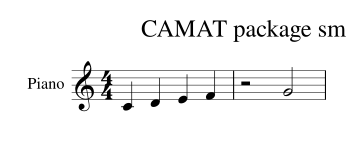

Processing (verovio): basic_musicxml_verovio.mei -> 00_basic_musicxml_verovio
Extracted non-barline MEI events: 5 event(s), types=['clef', 'key_sig', 'measure', 'meter_sig'].


,Measure,Local Onset,Global Onset,Duration,Pitch,MIDI,Voice,xml_id,grace,tied,slurred,tuplet,fermata,articulations,ornaments,technical,Logical Duration,Performed Duration
0,1,0.0,0.0,1.0,C4,60,Piano - Voice 1,mx-c4,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1.0,<NA>
1,1,1.0,1.0,1.0,D4,62,Piano - Voice 1,mx-d4,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1.0,<NA>
2,1,2.0,2.0,1.0,E4,64,Piano - Voice 1,mx-e4,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1.0,<NA>
3,1,3.0,3.0,1.0,F4,65,Piano - Voice 1,mx-f4,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1.0,<NA>
4,2,2.0,6.0,2.0,G4,67,Piano - Voice 1,mx-g4,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2.0,<NA>


Rows: 5, unique pitches: 5


,type,subtype,Measure,Local Onset,Global Onset,Duration,Voice,xml_id,start_xml_id,end_xml_id,...,wordpos,con,mm,mm_unit,mm_dots,measure_type,measure_metcon,measure_join,measure_n,extra
0,measure,<NA>,1.0,0.0,0.0,4.0,<NA>,iugz320,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1,<NA>
1,rest,rest,2.0,0.0,4.0,2.0,Piano - Voice 1,mx-rest,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,measure,<NA>,2.0,0.0,4.0,4.0,<NA>,b11cug6s,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2,<NA>
3,clef,G-2,NaN,NaN,NaN,0.0,Piano - Voice 1,f12lptl8,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,key_sig,0,NaN,NaN,NaN,0.0,Piano - Voice 1,g1y1s1gt,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
5,meter_sig,4/4,NaN,NaN,NaN,0.0,Piano - Voice 1,hwdbubr,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


Event rows: 6

Parsed DataFrames:
- 00_basic_musicxml_verovio: rows=5, unique_pitches=5, min_duration=1.0, voices=1 (['Piano - Voice 1'])


,Measure,Local Onset,Global Onset,Duration,Pitch,MIDI,Voice,xml_id,grace,tied,slurred,tuplet,fermata,articulations,ornaments,technical,Logical Duration,Performed Duration
0,1,0.0,0.0,1.0,C4,60,Piano - Voice 1,mx-c4,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1.0,<NA>
1,1,1.0,1.0,1.0,D4,62,Piano - Voice 1,mx-d4,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1.0,<NA>
2,1,2.0,2.0,1.0,E4,64,Piano - Voice 1,mx-e4,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1.0,<NA>
3,1,3.0,3.0,1.0,F4,65,Piano - Voice 1,mx-f4,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1.0,<NA>
4,2,2.0,6.0,2.0,G4,67,Piano - Voice 1,mx-g4,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2.0,<NA>


In [5]:
from camat import parse_files, vrv_display_svg, vrv_load_from_file, vrv_render_page, vrv_set_options

ok_records = [r for r in records if r.get("status") == "ok" and r.get("output_mei")]
if not ok_records:
    print("No successful conversion to preview.")
else:
    preview_path = ok_records[0]["output_mei"]
    print(preview_path)
    with vrv_quiet():
        vrv_set_options(pageWidth=1400, pageHeight=400, scale=40, breaks="none", removeIds=False)
        vrv_load_from_file(preview_path, input_from="mei")
        vrv_display_svg(vrv_render_page(1))

    results, dfs_by_name, last_df = parse_files(
        [preview_path],
        quiet_native_warnings=True,
        print_parsed_summary=True,
        backend="none",
        include_xml_ids=True,
        n_jobs=1,
    )
    display(last_df.head())

## Command line

The same helper is a script. From the repository root:

```bash
python scripts/test_verovio_conversion.py --source tests/fixtures/basic.musicxml --n-jobs 1
```

A newline-separated list file containing local paths and/or URLs:

```bash
python scripts/test_verovio_conversion.py --source notebooks/data/batch_sources.txt --n-jobs 1
```

The remote tutorial score comes from Craig Stuart Sapp's [Bach 370 Chorales](https://github.com/craigsapp/bach-370-chorales) edition ([CC BY-NC-SA 4.0](https://github.com/craigsapp/bach-370-chorales/blob/main/LICENSE.txt)). The maintainer probe with a larger source list remains `testing_verovio_conversion.ipynb`.